# Image Cropper

This prepares manuscript images for OCR.

### Crop double page spreads to make page detection easier

1. Enter the directory where the images are found and the amout of the boarders to crop
2. Test the output
3. Crop all the images and save to new directory


Box(children=(HTML(value='<h2>Test cropping a single file</h2>'), Box(children=(Label(value='Path to file'), T…

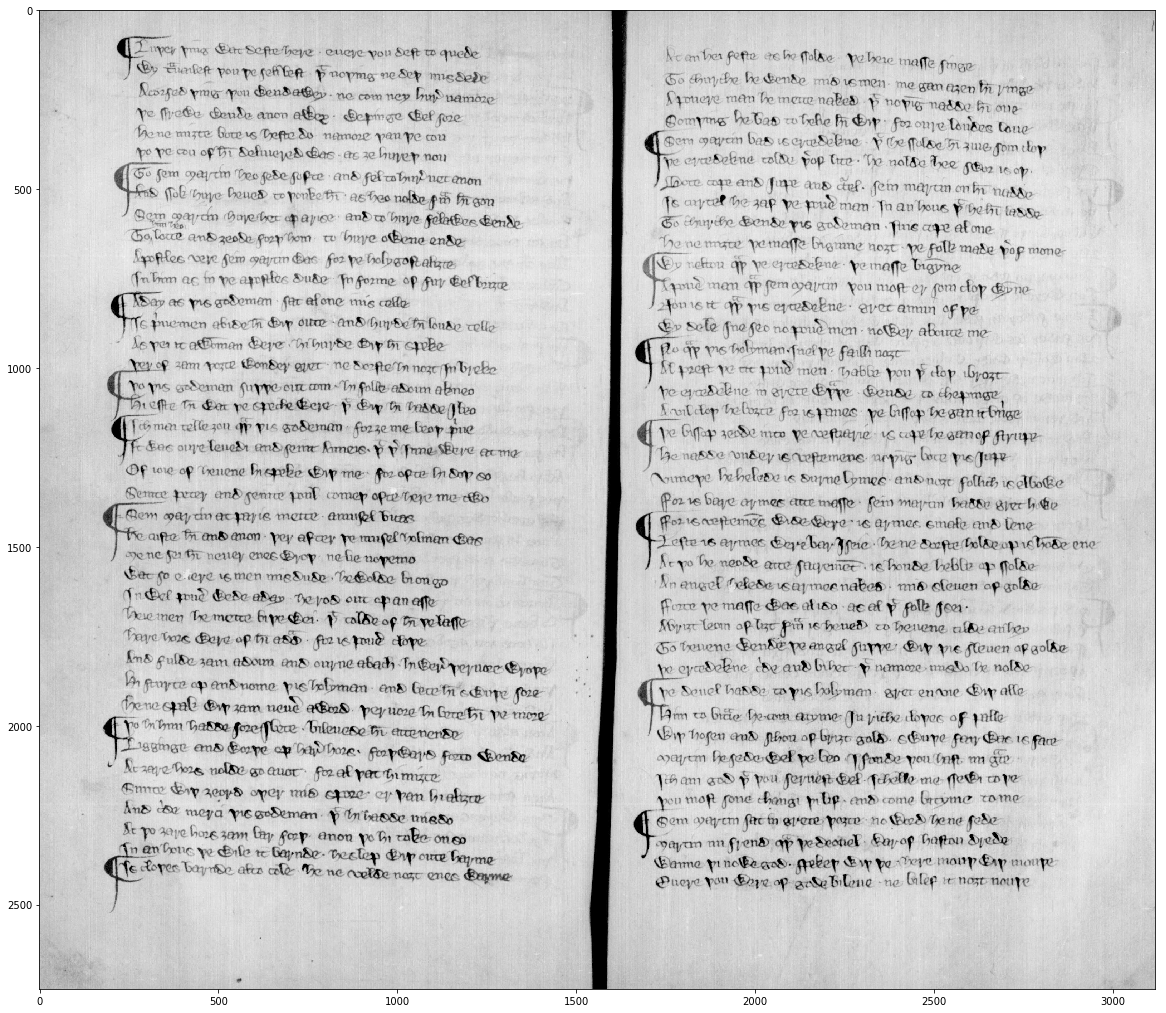

In [25]:
%config Application.log_level="INFO"
from ocr.helpers import implt
from ipywidgets import Text, Layout, Button, Box, Dropdown, Label, IntText, HTML
from lib.ImageProcessor import crop_dp_spread

form_item_layout = Layout(
    display='flex',
    flex_flow='row',
    justify_content='space-between'
)

file_path, top, bottom, left, right = Text(), IntText(value=0), IntText(value=0), IntText(value=0), IntText(value=0)

submit_button = Button(description='Submit', disabled=False, button_style='success', layout=form_item_layout)

header = HTML(
    value="<h2>Test cropping a single file</h2>"
)

form_items = [
    header,
    Box([Label(value='Path to file'), file_path], layout=form_item_layout),
    Box([Label(value='Crop from top'), top], layout=form_item_layout),
    Box([Label(value='Crop from bottom'), bottom], layout=form_item_layout),
    Box([Label(value='Crop from left'), left], layout=form_item_layout),
    Box([Label(value='Crop from right'), right], layout=form_item_layout),
    submit_button
]

image_input_form = Box(form_items, layout=Layout(
    display='flex',
    flex_flow='column',
    border='solid 2px',
    align_items='stretch',
    width='50%'
))

def validate_image_input_form():
    valid = None
    for input in [file_path, top, bottom, left, right]:
        if input.value == '':
            print('You must provide a value for each item in form')
            valid = False
        else:
            valid = True
    return valid

def handle_submit(submit_button):
    if validate_image_input_form():
        cropped_image = crop_dp_spread(file_path.value, top.value, bottom.value, left.value, right.value)
        implt(cropped_image, 'gray')

submit_button.on_click(handle_submit)
image_input_form

### Cut double page spreads into single pages and rename files

1. Enter the directory where the images are found
2. Enter the directory where you want to save the new images
3. Enter the index of the first folio to be numbered
4. Enter the side of the first folio to be numbered (may only be *r* or *v*)
5. Enter the first folio's page / folio number
6. Enter the siglum of the MS for the file names.

Expected filename will be something like: `N_173v.jpg`

In [8]:
%config Application.log_level="INFO"
from ipywidgets import Text, Layout, Button, Box, Dropdown, Label, IntText
from lib import ImageProcessor
from lib.ImageProcessor import rename_images_in_directory

form_item_layout = Layout(
    display='flex',
    flex_flow='row',
    justify_content='space-between'
)

FOLIO_SIDES = ('r', 'v')

input_dir, out_dir, first_fol_ind, first_fol_side, start_fol, siglum = \
    Text(), Text(), IntText(value=0), Dropdown(options=FOLIO_SIDES), IntText(value=1), Text()

submit_button = Button(description='Submit', disabled=False, button_style='success', layout=form_item_layout)
    
form_items = [
    Box([Label(value='Image Directory'), input_dir], layout=form_item_layout),
    Box([Label(value='Output Directory'), out_dir], layout=form_item_layout),
    Box([Label(value='Index of first folio'), first_fol_ind], layout=form_item_layout),
    Box([Label(value='Side of first folio'), first_fol_side], layout=form_item_layout),
    Box([Label(value='Start of foliation'), start_fol], layout=form_item_layout),
    Box([Label(value='MS siglum'), siglum], layout=form_item_layout),
    submit_button
]

image_input_form = Box(form_items, layout=Layout(
    display='flex',
    flex_flow='column',
    border='solid 2px',
    align_items='stretch',
    width='50%'
))

def validate_image_input_form():
    valid = None
    for input in [input_dir, out_dir, siglum]:
        if input.value == '':
            print('You must provide a value for each item in form')
            valid = False
        else:
            valid = True
    return valid

def format_page_data(first_fol_ind, first_fol_side, start_fol):
    return { 'start_index': first_fol_ind, 'start_side': first_fol_side, 'start_folio':  start_fol }

def handle_submit(submit_button):
    if validate_image_input_form():
        page_data = format_page_data(first_fol_ind.value, first_fol_side.value, start_fol.value)
        rename_images_in_directory(input_dir.value, out_dir.value, siglum.value, page_data)

submit_button.on_click(handle_submit)
image_input_form

Box(children=(Box(children=(Label(value='Image Directory'), Text(value='')), layout=Layout(display='flex', fle…

3136 3520


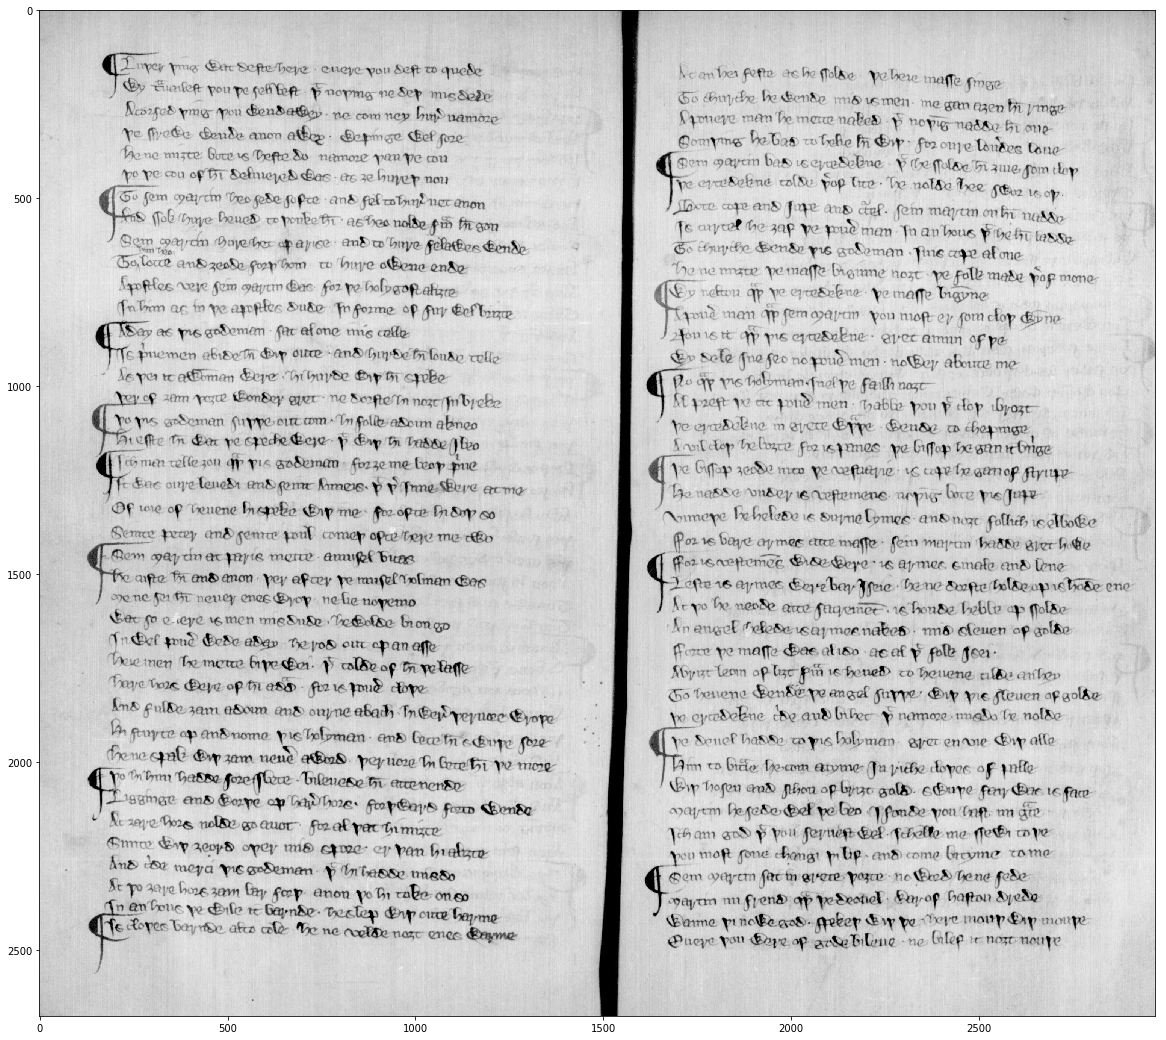

In [9]:
import cv2
import matplotlib.pyplot as plt
from ocr.helpers import implt, resize, ratio

img = cv2.imread("images/input_N/N_73v_74r.JPG")
height, width, _ = img.shape
print(height, width)
crop_img = img[160:height-300, 250:width-300]
implt(crop_img, 'gray')